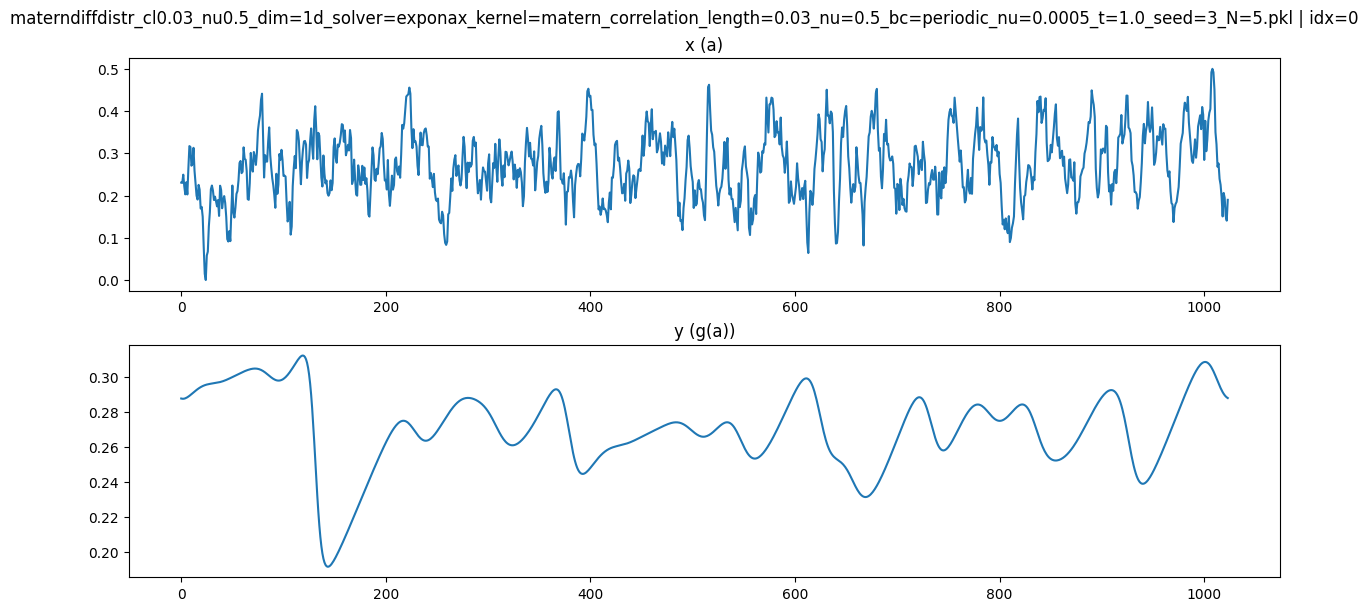

In [5]:
import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def to_nan_where_invalid(arr):
    arr = np.asarray(arr)
    out = arr.copy()
    out[~np.isfinite(out)] = np.nan
    return out

def squeeze_to_1d(arr):
    arr = np.asarray(arr)
    arr = np.squeeze(arr)
    if arr.ndim > 1:
        arr = arr.reshape(-1)
    return arr

def load_xy_from_pickle(pkl_path, index=0):
    with open(pkl_path, 'rb') as f:
        obj = pickle.load(f)

    if isinstance(obj, list):
        if not obj:
            raise ValueError("该 pickle 列表为空！")
        rec = obj[index]
        if not isinstance(rec, dict):
            raise TypeError(f"期望 list[dict]，但第 {index} 个元素类型为 {type(rec)}")
        x = rec.get('a', rec.get('x'))
        y = rec.get('g(a)', rec.get('y'))
        if x is None or y is None:
            raise KeyError("找不到需要的键：'a'/'x' 或 'g(a)'/'y'")
        return np.asarray(x), np.asarray(y)

    if isinstance(obj, dict):
        x = obj.get('a', obj.get('x'))
        y = obj.get('g(a)', obj.get('y'))
        if x is None or y is None:
            raise KeyError("找不到需要的键：'a'/'x' 或 'g(a)'/'y'")
        return np.asarray(x), np.asarray(y)

    raise TypeError(f"不支持的 pickle 顶层类型：{type(obj)}")

def plot_xy(x, y, title=None):
    x = squeeze_to_1d(x)
    y = squeeze_to_1d(y)
    x_plot = to_nan_where_invalid(x)
    y_plot = to_nan_where_invalid(y)

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)
    axes[0].plot(x_plot); axes[0].set_title('x (a)')
    axes[1].plot(y_plot); axes[1].set_title('y (g(a))')
    if title: fig.suptitle(title)
    return fig

# ==== 用法 ====
# pkl_path = "../datasets/range_0_3/matern_diff_distr/materndiffdistr_cl0.03_nu0.5_dim=1d_solver=exponax_kernel=matern_correlation_length=0.03_nu=0.5_bc=periodic_nu=0.0005_t=1.0_seed=3_N=5.pkl"  # 改成你的路径
pkl_path = "../datasets/range_0_0.5/matern_diff_distr/materndiffdistr_cl0.03_nu0.5_dim=1d_solver=exponax_kernel=matern_correlation_length=0.03_nu=0.5_bc=periodic_nu=0.0005_t=1.0_seed=3_N=5.pkl"  # 改成你的路径

idx = 0                         # 选第几个样本
x, y = load_xy_from_pickle(pkl_path, idx)
fig = plot_xy(x, y, title=f"{Path(pkl_path).name} | idx={idx}")
plt.show()
# 如需保存：fig.savefig("out.png", dpi=150, bbox_inches="tight")
